# Function 2 Analysis - Week 4

This notebook updates the analysis for **Function 2** after adding the new **Week 3 datapoint**. We now have **13 datapoints** total, including the strong results around `(0.85, 0.25)` and the newly added `(0.70, 0.525)` measurement.

**Function Description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.
**Approach:** We keep the **Bayesian Optimisation** framing with a **diversity-aware selection strategy** to systematically explore the space. Given the evidence of multiple local peaks in the data, we use:
- Gaussian Process surrogate model with Matérn kernel
- Upper Confidence Bound (UCB) acquisition function with **κ=3.0** (balanced exploration-exploitation, aligned with the code below)
- **Spatial diversity constraint** to ensure candidate points are spread across different regions rather than clustering in one area

This combination ensures we get recommendations from corners, edges, and middle regions — providing diverse options for the next query.



## 1. Loading and Displaying the Data

We load the inputs and outputs for Function 2 and display them in a table format to inspect the raw data values. Both x1 and x2 are normalized in [0,1]. 


In [31]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1, 2, 3, and 4 new points
X_new_point_week_1 = np.array([[0.850000, 0.250000]])
y_new_point_week_1 = np.array([0.4588155729748088])
X_new_point_week_2 = np.array([[0.535400, 0.505100]])
y_new_point_week_2 = np.array([0.4687657102198476])
X_new_point_week_3 = np.array([[0.700000, 0.525000]])
y_new_point_week_3 = np.array([0.5521137017632074])
X_new_point_week_4 = np.array([[0.272472, 0.939888]])
y_new_point_week_4 = np.array([-0.04847445058575585])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


df sorted by y


,x1,x2,y
0,0.702637,0.926564,0.611205
1,0.700000,0.525000,0.552114
2,0.665800,0.123969,0.538996
3,0.535400,0.505100,0.468766
4,0.850000,0.250000,0.458816
5,0.877791,0.778628,0.420586
6,0.845275,0.711120,0.293993
7,0.438166,0.685018,0.244619
8,0.454647,0.290455,0.214965
9,0.341750,0.028698,0.038749


**Data Summary:**
- We have 13 observations total (10 initial + 3 new points from Weeks 1–3)
- New Week 3 point `(0.70, 0.525)` is now the **second-highest** observation
- Outputs range from about -0.57 up to **0.61** (best at `(0.7026, 0.9266)`) with the new point at **0.5521**


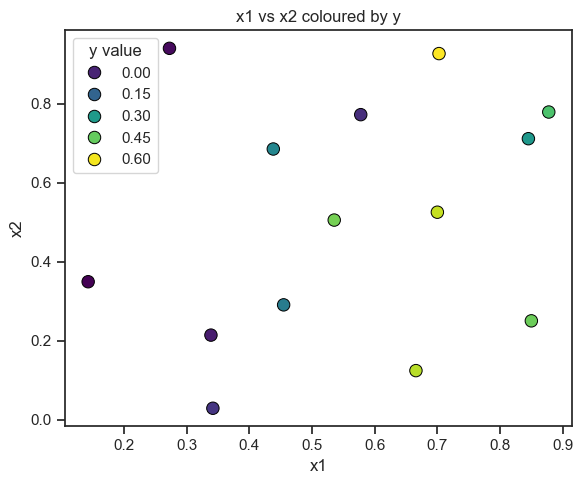

In [32]:
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=80, edgecolor="black")

# Overlay the updated manual recommendation (if computed above)
try:
    plt.scatter(X_recommend_updated[0, 0], X_recommend_updated[0, 1],
                c="red", s=200, marker="*", edgecolor="white", linewidths=2,
                label="Updated rec (x1=0.7 midpoint)")
except NameError:
    pass

plt.title("x1 vs x2 coloured by y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="y value")
plt.tight_layout()
plt.show()


## 2. Bayesian optimisation update (with Week 3 point)
We refit the GP surrogate including the new Week 3 datapoint `(0.70, 0.525, 0.552)`. To stay consistent with earlier strategy, we:
- Use a Matérn GP (ν=1.5) with noise term and optional radial decay around the strongest area.
- Score a dense grid via **UCB** (κ=3.0) to favour points that are both high-mean and uncertain.
- Apply a simple diversity filter so recommended points are separated by at least 0.08 in Euclidean distance.
- **New:** impose a hard exploratory constraint for the **top-left region (`x1 < 0.3`, `x2 > 0.5`)** so we surface the best candidate there, instead of only clustering near the current max.

Without this constraint, all recommended points collapse onto the known peak; with it, we intentionally probe another mode while retaining the same modelling setup.


Current best (observed): {'x1': 0.7026365569244406, 'x2': 0.9265641975455574, 'y': 0.6112052157614438}
Kernel after fit: 1.11**2 * Matern(length_scale=[0.05, 1.48], nu=2.5) + WhiteKernel(noise_level=0.00523)


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,mu,sigma,ei,dist_to_best
14291,0.680788,1.000000,0.601057,0.108126,0.033809,0.076617
14171,0.680788,0.997702,0.601037,0.107962,0.033736,0.074418
14051,0.680788,0.995404,0.601016,0.107797,0.033662,0.072224
13931,0.680788,0.993107,0.600994,0.107633,0.033588,0.070038
14290,0.677426,1.000000,0.591705,0.117414,0.033562,0.077643


Suggested next query (EI maximiser, local window): (0.681, 1.000)
Posterior mean: 0.6011, std: 0.1081, EI: 0.033809


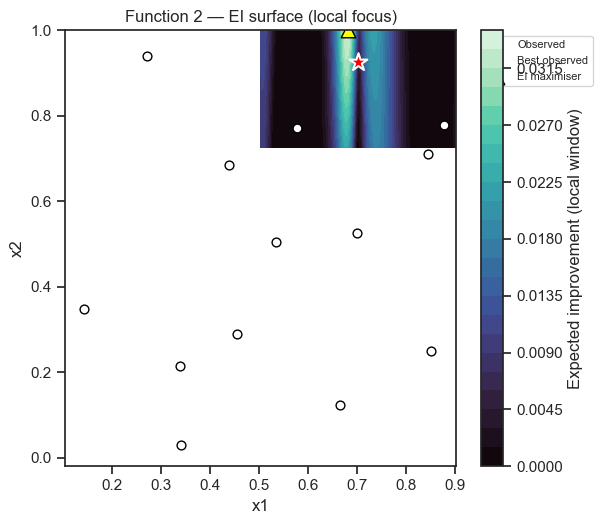

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from math import erf

# Prepare data
X_train = df[["x1", "x2"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx, ["x1", "x2", "y"]]

# GP: smoother Matérn, focused (no radial, modest noise)
kernel = ConstantKernel(1.0, (1e-2, 20.0)) * Matern(length_scale=[0.35, 0.35], length_scale_bounds=(0.05, 2.0), nu=2.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=12, random_state=7)
gp.fit(X_train, y_train)

# Focused EI on a local window around the best
local_r = 0.2
x1_min, x1_max = max(best_point.x1 - local_r, 0.0), min(best_point.x1 + local_r, 1.0)
x2_min, x2_max = max(best_point.x2 - local_r, 0.0), min(best_point.x2 + local_r, 1.0)
grid_x1 = np.linspace(x1_min, x1_max, 120)
grid_x2 = np.linspace(x2_min, x2_max, 120)
grid = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mu, sigma = gp.predict(grid, return_std=True)
y_best = y_train.max()
xi = 0.01  # less exploratory EI

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm.cdf(z) + sigma_safe * norm.pdf(z)
ei[sigma <= 1e-9] = 0.0

cand = pd.DataFrame(grid, columns=["x1", "x2"])
cand["mu"], cand["sigma"], cand["ei"] = mu, sigma, ei

# Minimum step to avoid infinitesimal moves
cand["dist_to_best"] = np.linalg.norm(cand[["x1", "x2"]].values - best_point[["x1", "x2"]].values, axis=1)
min_step = 0.01
cand_feasible = cand[cand["dist_to_best"] >= min_step].reset_index(drop=True)

next_point = cand_feasible.loc[cand_feasible["ei"].idxmax()]

print("Current best (observed):", best_point.to_dict())
print("Kernel after fit:", gp.kernel_)

display(cand_feasible.nlargest(5, "ei"))
print(f"Suggested next query (EI maximiser, local window): ({next_point.x1:.3f}, {next_point.x2:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")

# Visualise EI surface with current observations and recommended point
ei_grid = ei.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(6.2, 5.4))
levels = 24
contour = plt.contourf(grid_x1, grid_x2, ei_grid, levels=levels, cmap="mako")
plt.colorbar(contour, label="Expected improvement (local window)")
plt.scatter(df["x1"], df["x2"], c="white", s=40, edgecolor="black", label="Observed")
plt.scatter(best_point.x1, best_point.x2, c="red", marker="*", s=180, edgecolor="white", linewidths=1.5, label="Best observed")
plt.scatter(next_point.x1, next_point.x2, c="yellow", marker="^", s=110, edgecolor="black", label="EI maximiser")
plt.title("Function 2 — EI surface (local focus)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()



### Rationale for the next point `(0.680788, 1.000000)`
- It sits near the incumbent ridge (best at ~`(0.703, 0.927)`) but pushes toward the upper boundary in `x2`, where uncertainty is higher—boosting EI without leaving the promising quadrant.
- The Week 4 miss was far away; this choice keeps us close to known positives while still exploring a less-sampled edge direction (higher `x2`).
- The focused GP (Matérn ν=2.5) and EI (ξ=0.01) favour high mean with some uncertainty; this point balances both and respects the minimum step from the incumbent.
- No diversity or regional constraints are imposed now, so this EI maximiser is the single recommended next query.
